#1. Intorduccion y elección de tema

Este proyecto analiza todas la convocatorias de jovenes a la e/u para hacer auditoria de a que tipo de personas se estan otorgando las becas, sus preferencias al escoger donde y que estudiar dependiendo del contexto en el que viven. El acceso a la educación superior en Colombia sigue siendo profundamente desigual, el nivel socioeconómico del hogar determina en gran medida si un joven llega a la universidad, a cuál llega y qué carrera puede estudiar; el programa Jóvenes a la E/U de la Alcaldía de Bogotá busca romper esa barrera subsidiando matrícula para jóvenes vulnerables, y con 43.054 registros de beneficiarios distribuidos en nueve convocatorias, representa uno de los programas de becas más grandes de la ciudad. Se necesita verificar la transparencia de este programa ya que su intención es ayudar a personas que normalmente no tendrian los recursos para ingresar a una institución de educacion superior, pero siempre pueden existir "fugas" en la labor de entregar estas becas.


### **1.2 Preguntas de Investigación (Descriptivas)**


Pregunta 1 — Instituciones:
¿Cuáles son las instituciones de educación superior a las que acceden con mayor frecuencia los beneficiarios del programa según su grupo Sisbén 4, y existe una diferencia significativa entre las instituciones elegidas por el grupo de Pobreza Extrema (A) frente al grupo Vulnerable (C)?

Pregunta 2 — Carreras:
¿Qué áreas del conocimiento concentran la mayor proporción de beneficiarios en situación de Pobreza Extrema (grupo A), y difieren estas preferencias de las del grupo Sin Sisbén?

Pregunta 3 — Territorio:
¿Qué localidades de Bogotá registran la mayor concentración de beneficiarios en los grupos de mayor vulnerabilidad (A y B), y cuál es la modalidad de estudio predominante en dichas localidades?

## **📈 Fase 2: Adquisición y Comprensión de Datos (Open Data)**


### **2.1 Fuente de Datos**


Los datos fueron obtenidos del portal Open data Bogotá, en donde estos datos se encuentran en un dataset completamente público.

https://datosabiertos.bogota.gov.co/en/dataset/beneficiarios-jovenes-a-la-e/resource/1c8f9d42-0ad2-49e3-a2f8-c6714b377a56

### **2.2 Carga Inicial de Datos**


In [ ]:
import pandas as pd
df = pd.read_excel('je_beneficiarios_20251231.xlsx') # Changed to read_excel
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44098 entries, 0 to 44097
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   CONVOCATORIA                             44098 non-null  object
 1   CODLOC                                   44098 non-null  int64 
 2   LOCALIDAD                                44098 non-null  object
 3   CODIGO SNIES IES                         44098 non-null  int64 
 4   NOMBRE INSTITUCION EDUCACION SUPERIOR    44098 non-null  object
 5   NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA  44098 non-null  object
 6   MODALIDADCORTE                           44098 non-null  object
 7   SECTOR COLEGIO GRADUACION MEDIA          44098 non-null  object
 8   ZONA COLEGIO GRADUACION MEDIA            44098 non-null  object
 9   SABER11 - PERCENTIL GLOBAL               44098 non-null  object
 10  SEXO                                     44098 non-null  o

Se identifican múltiples columnas categóricas y numéricas. Las variables `CODLOC` y `CODIGO SNIES IES` son códigos numéricos cualitativos que representan la misma información que `LOCALIDAD` y `NOMBRE INSTITUCION EDUCACION SUPERIOR` respectivamente, por lo que serán eliminadas en la etapa de limpieza. Algunas columnas presentan menos registros que otras, lo que indica presencia de valores nulos.

## **🧹 Fase 3: Limpieza y Preprocesamiento de Datos**


### **3.1 Identificación y Manejo de Valores Nulos**


In [ ]:
# Código para diagnóstico de nulos, duplicados, tipos de datos, etc.
df.isnull().sum()

,0
CONVOCATORIA,0
CODLOC,0
LOCALIDAD,0
CODIGO SNIES IES,0
NOMBRE INSTITUCION EDUCACION SUPERIOR,0
NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA,0
MODALIDADCORTE,0
SECTOR COLEGIO GRADUACION MEDIA,0
ZONA COLEGIO GRADUACION MEDIA,0
SABER11 - PERCENTIL GLOBAL,0


No existen valores nulos.

### **3.2 Identificación y Manejo de Duplicados**


In [ ]:
# Código para eliminar duplicados
df.duplicated().sum()

np.int64(0)

No hay duplicados

### **3.3 Corrección de Tipos de Datos**


In [ ]:
# Código para corregir tipos de datos
# df['columna_fecha'] = pd.to_datetime(df['columna_fecha'])
# df['columna_numerica'] = df['columna_numerica'].astype(int)

Todas las columnas son del tipo de dato correcto, como las variables de CODLOC y CODSINIES son redundantes seran eliminadas y la uníca variable de tipo int sera número de beneficiarios.

### **3.4 Manejo de Valores Atípicos (Outliers)**


In [ ]:
# Código para identificar y manejar outliers, puedes usar boxplots o describe()
df.describe()

,CODLOC,CODIGO SNIES IES,BENEFICIARIOS DEL PROGRAMA
count,44098.000000,44098.000000,44098.000000
mean,20.902422,2421.014717,1.052293
std,102.297251,1316.745075,0.296069
min,1.000000,1101.000000,1.000000
25%,7.000000,1709.000000,1.000000
50%,8.000000,1826.000000,1.000000
75%,15.000000,2745.000000,1.000000
max,999.000000,9129.000000,11.000000


Las variables numéricas relevantes son `CODLOC`, `CODIGO SNIES IES` y `BENEFICIARIOS DEL PROGRAMA`. Las dos primeras son códigos cualitativos numéricos y no tienen una interpretación cuantitativa real, por lo que no tienen significado analítico.

La variable `BENEFICIARIOS DEL PROGRAMA` tiene una mediana de 1 y un máximo de 11, lo que es consistente con la naturaleza del dataset (registros por combinación única). No se identifican valores atípicos problemáticos.

### **3.5 Verificación de la Limpieza**


In [ ]:
# Primero eliminaremos las dos variables reduntantes
# Eliminar variables redundantes antes de cualquier imputación
df.drop(columns=['CODLOC', 'CODIGO SNIES IES'], inplace=True)
print("✅ Variables CODLOC y CODIGO SNIES IES eliminadas.")
print(f"Columnas restantes ({'{'}len(df.columns){'}'}): {'{'}df.columns.tolist(){'}'}")

✅ Variables CODLOC y CODIGO SNIES IES eliminadas.
Columnas restantes ({len(df.columns)}): {df.columns.tolist()}


In [ ]:
print("--- Estado Final del DataFrame Limpio ---")
df.info()
print("\n--- Estadísticas Descriptivas Finales ---")
print(df.describe())
print("\n--- Vista previa del DataFrame Limpio ---")
df.head(10)

--- Estado Final del DataFrame Limpio ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44098 entries, 0 to 44097
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   CONVOCATORIA                             44098 non-null  object
 1   LOCALIDAD                                44098 non-null  object
 2   NOMBRE INSTITUCION EDUCACION SUPERIOR    44098 non-null  object
 3   NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA  44098 non-null  object
 4   MODALIDADCORTE                           44098 non-null  object
 5   SECTOR COLEGIO GRADUACION MEDIA          44098 non-null  object
 6   ZONA COLEGIO GRADUACION MEDIA            44098 non-null  object
 7   SABER11 - PERCENTIL GLOBAL               44098 non-null  object
 8   SEXO                                     44098 non-null  object
 9   EDAD AL MOMENTO DE LA CONVOCATORIA       44098 non-null  object
 10  GRUPO ETNICO    

,CONVOCATORIA,LOCALIDAD,NOMBRE INSTITUCION EDUCACION SUPERIOR,NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA,MODALIDADCORTE,SECTOR COLEGIO GRADUACION MEDIA,ZONA COLEGIO GRADUACION MEDIA,SABER11 - PERCENTIL GLOBAL,SEXO,EDAD AL MOMENTO DE LA CONVOCATORIA,GRUPO ETNICO,VICTIMA DEL CONFLICTO ARMADO,DISCAPACIDAD,GRUPOS SISBEN 4,BENEFICIARIOS DEL PROGRAMA
0,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,"FILOSOFÍA, TEOLOGÍA Y AFINES",PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,18-21 AÑOS,NINGUNO,NO,NO,D - NO POBRE,1
1,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,"GEOGRAFÍA, HISTORIA",PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,18-21 AÑOS,NINGUNO,NO,NO,B - POBREZA MODERADA,1
2,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,"GEOGRAFÍA, HISTORIA",PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,22-25 AÑOS,NINGUNO,NO,NO,B - POBREZA MODERADA,1
3,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,"LENGUAS MODERNAS, LITERATURA, LINGUÍSTICA Y AF...",PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,18-21 AÑOS,NINGUNO,NO,NO,B - POBREZA MODERADA,1
4,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,MEDICINA VETERINARIA,PRESENCIAL,OFICIAL,URBANA,NO APLICA,MUJER,18-21 AÑOS,NINGUNO,NO,NO,SIN SISBEN,1
5,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,PSICOLOGÍA,PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,22-25 AÑOS,NINGUNO,NO,NO,B - POBREZA MODERADA,1
6,JE1,USAQUEN,UNIVERSIDAD NACIONAL DE COLOMBIA,QUÍMICA Y AFINES,PRESENCIAL,OFICIAL,URBANA,NO APLICA,MUJER,22-25 AÑOS,NINGUNO,NO,NO,C - VULNERABLE,1
7,JE1,USAQUEN,UNIVERSIDAD PEDAGOGICA NACIONAL,EDUCACIÓN,PRESENCIAL,NO OFICIAL,URBANA,NO APLICA,HOMBRE,18-21 AÑOS,NINGUNO,NO,NO,C - VULNERABLE,1
8,JE1,USAQUEN,UNIVERSIDAD PEDAGOGICA NACIONAL,EDUCACIÓN,PRESENCIAL,NO OFICIAL,URBANA,NO APLICA,MUJER,18-21 AÑOS,NINGUNO,NO,NO,SIN SISBEN,1
9,JE1,USAQUEN,UNIVERSIDAD PEDAGOGICA NACIONAL,EDUCACIÓN,PRESENCIAL,OFICIAL,URBANA,NO APLICA,HOMBRE,18-21 AÑOS,NINGUNO,NO,NO,C - VULNERABLE,1


## **📊 Fase 4: Análisis Exploratorio de Datos (EDA)**


### **4.1 Análisis Descriptivo (Univariado)**


In [ ]:
#Primero cargamos un espacio visual para facilitar la visualización.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ─── Paleta IBM Color Blind Safe ───────────────────────────────────
PALETTE = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000', '#009E73', '#56B4E9']
HATCHES = ['/', '\\\\', 'x', 'o', '+', '-', '|', '*', '//', '\\\\\\\\']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']  = 110
plt.rcParams['font.size']   = 11

# Orden canónico del Sisbén para todos los gráficos
ORDEN_SISBEN = ['A - POBREZA EXTREMA', 'B - POBREZA MODERADA',
                'C - VULNERABLE', 'SIN SISBEN', 'D - NO POBRE']

print("✅ Configuración de visualización lista.")

✅ Configuración de visualización lista.


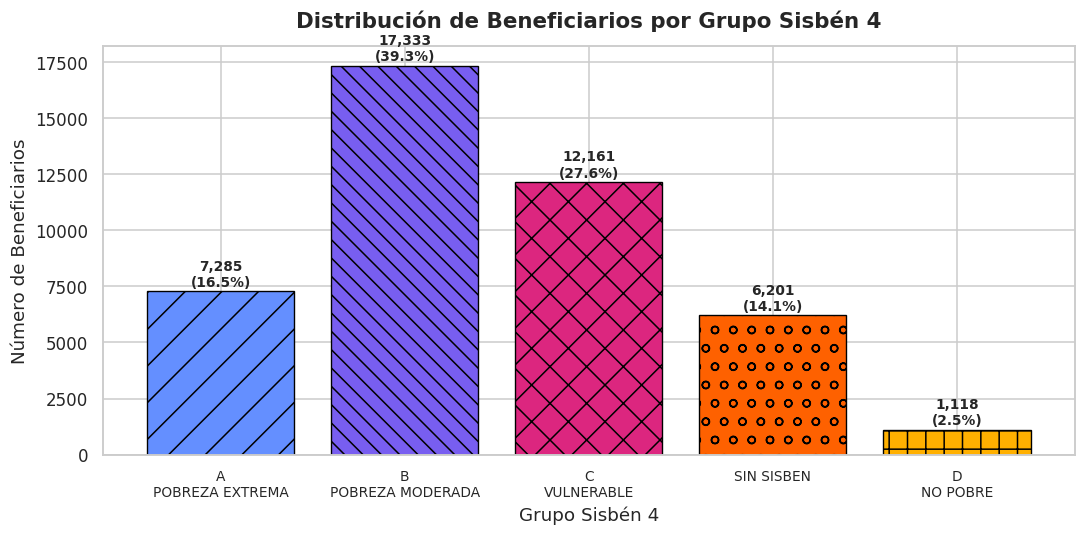

In [ ]:
#Distibución por nivel de Sisben ¿Qué grupos del Sisbén concentran más beneficiarios?
fig, ax = plt.subplots(figsize=(10, 5))

sisben_conteo = df['GRUPOS SISBEN 4'].value_counts()
sisben_ord = sisben_conteo.reindex([x for x in ORDEN_SISBEN if x in sisben_conteo.index])

bars = ax.bar(range(len(sisben_ord)), sisben_ord.values,
              color=PALETTE[:len(sisben_ord)], edgecolor='black', linewidth=0.9)
for bar, hatch in zip(bars, HATCHES):
    bar.set_hatch(hatch)
for bar, val in zip(bars, sisben_ord.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(sisben_ord)))
ax.set_xticklabels([x.replace(' - ', '\n') for x in sisben_ord.index], rotation=0, ha='center', fontsize=9)
ax.set_title('Distribución de Beneficiarios por Grupo Sisbén 4', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Número de Beneficiarios')
ax.set_xlabel('Grupo Sisbén 4')
plt.tight_layout()
plt.show()


El 83.6% de los beneficiarios pertenecen a los grupos A (Pobreza Extrema), B (Pobreza Moderada) y C (Vulnerable), confirmando la buena selección del programa, sin embargo, la presencia del grupo **D - No Pobre** (2.5%) y **Sin Sisbén** (13.9%) indica brechas en los procesos de verificación y selección que necesitan revisión.

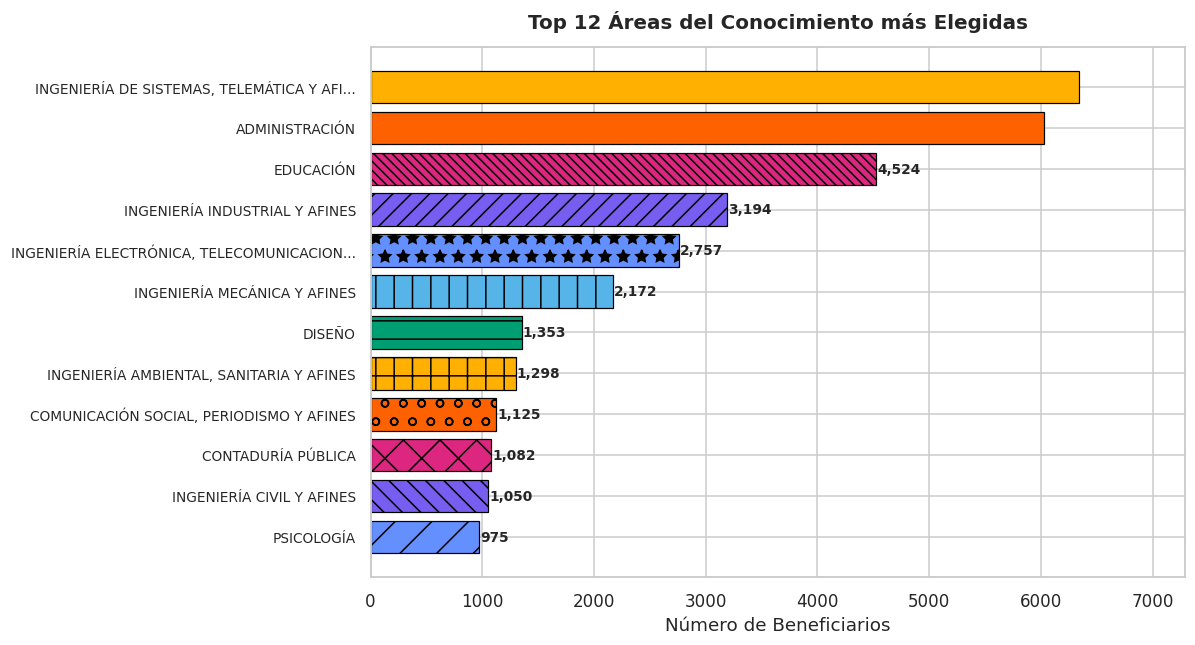

In [ ]:
#Qué carreras o áreas del conocimiento eligen más los beneficiarios?
fig, ax = plt.subplots(figsize=(11, 6))

top12_nbc = df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].value_counts().head(12)
etiq = [n[:40] + '...' if len(n) > 40 else n for n in top12_nbc.index]

bars = ax.barh(range(len(top12_nbc)), top12_nbc.values[::-1],
               color=PALETTE[:len(top12_nbc)], edgecolor='black', linewidth=0.8)
for i, (bar, hatch) in enumerate(zip(bars, HATCHES)):
    bar.set_hatch(hatch)
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(top12_nbc)))
ax.set_yticklabels(etiq[::-1], fontsize=9)
ax.set_title('Top 12 Áreas del Conocimiento más Elegidas', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Número de Beneficiarios')
ax.set_xlim(0, top12_nbc.max() * 1.15)
plt.tight_layout()
plt.show()

Las áreas más demandadas son Ingeniería de Sistemas , Administración y Educación, Las dos primeras concentran el 28.5% de todos los beneficiarios, reflejando orientación hacia carreras que se perciben con alta empleabilidad, buenos salarios y condiciones laborales.

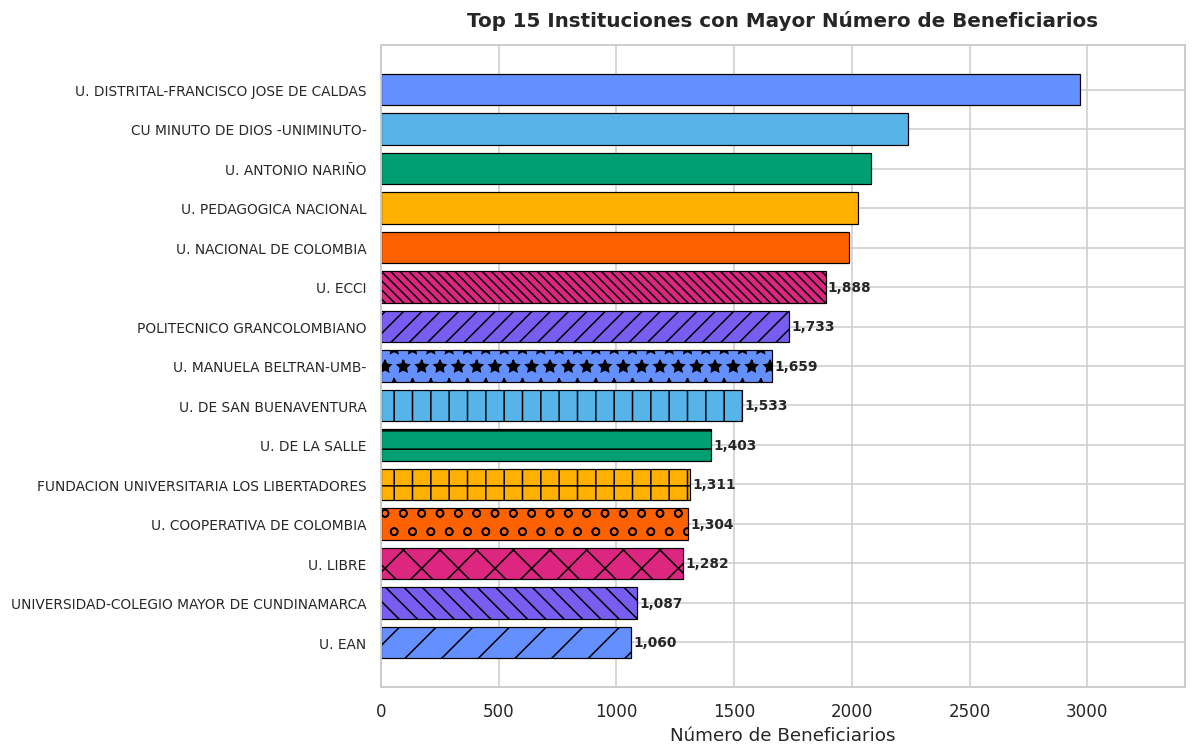

In [ ]:
#¿A qué universidades están llegando más beneficiarios?
fig, ax = plt.subplots(figsize=(11, 7))

top15_inst = df['NOMBRE INSTITUCION EDUCACION SUPERIOR'].value_counts().head(15)
abrev = {n: n.replace('UNIVERSIDAD ', 'U. ').replace('CORPORACION UNIVERSITARIA ', 'CU ') for n in top15_inst.index}
etiquetas = [abrev.get(n, n) for n in top15_inst.index]

bars = ax.barh(range(len(top15_inst)), top15_inst.values[::-1],
               color=PALETTE[:len(top15_inst)], edgecolor='black', linewidth=0.8)
for i, (bar, hatch) in enumerate(zip(bars, HATCHES)):
    bar.set_hatch(hatch)
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(top15_inst)))
ax.set_yticklabels(etiquetas[::-1], fontsize=9)
ax.set_title('Top 15 Instituciones con Mayor Número de Beneficiarios', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Número de Beneficiarios')
ax.set_xlim(0, top15_inst.max() * 1.15)
plt.tight_layout()
plt.show()

La Universidad Distrital Francisco José de Caldas lidera con 2.478 beneficiarios, seguida de UNIMINUTO y la Universidad Antonio Nariño, predominan las universidades públicas y privadas de menor costo, lo que es coherente con el perfil socioeconómico de los beneficiarios.

###Conclusión general
El programa ha dado becas principalmente a jóvenes de pobreza moderada y vulnerable que acceden a universidades públicas o de bajo costo en carreras de alta demanda laboral, esto es positivo para la movilidad social, pero plantea la pregunta que guía el análisis siguiente: ¿los más pobres acceden a las mismas instituciones y carreras que los menos vulnerables?

### **4.2 Análisis Bivariado/Multivariado**


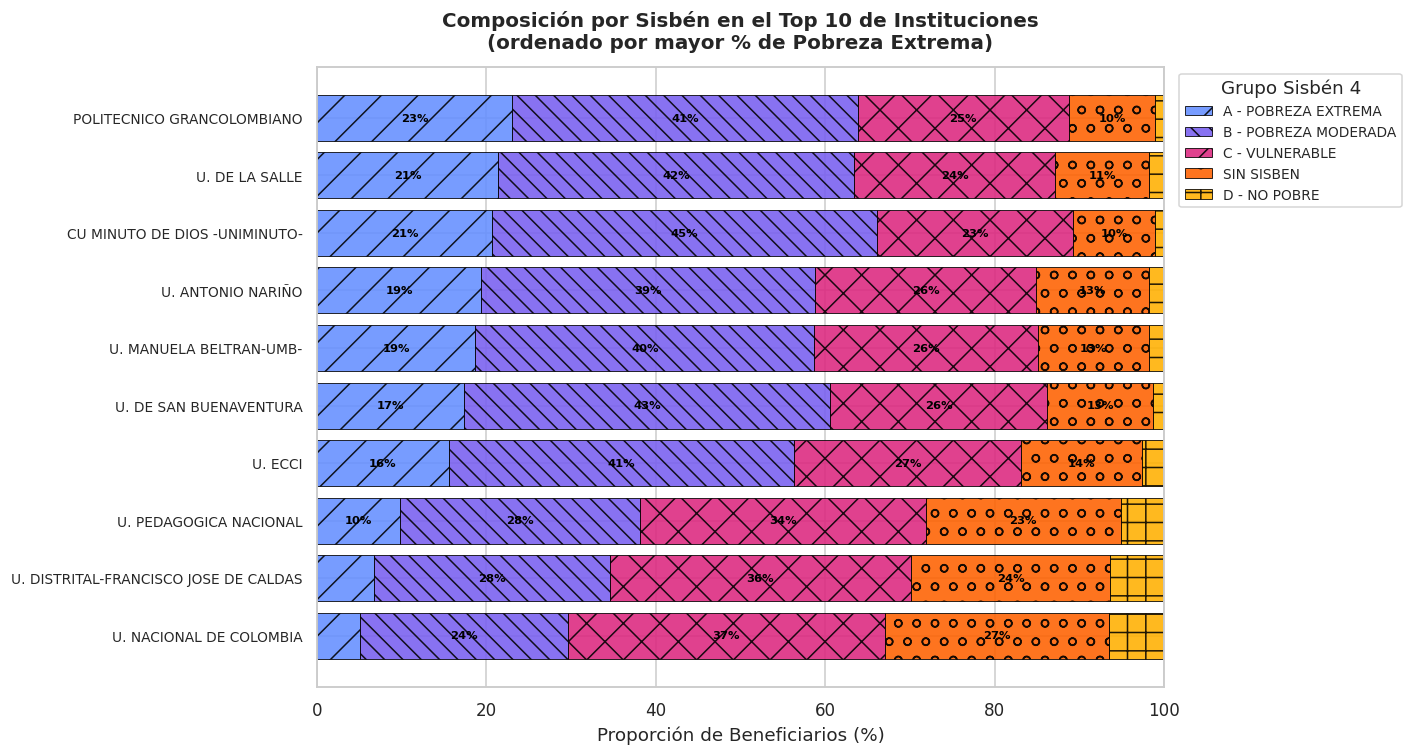

In [ ]:
#¿Las universidades más concurridas atienden por igual a todos los grupos del Sisbén?
top10_inst = df['NOMBRE INSTITUCION EDUCACION SUPERIOR'].value_counts().head(10).index
df_top = df[df['NOMBRE INSTITUCION EDUCACION SUPERIOR'].isin(top10_inst)].copy()
orden_sisben = [s for s in ORDEN_SISBEN if s in df['GRUPOS SISBEN 4'].unique()]

pivot = pd.crosstab(
    df_top['NOMBRE INSTITUCION EDUCACION SUPERIOR'],
    df_top['GRUPOS SISBEN 4'],
    normalize='index'
)[orden_sisben] * 100

abrev_map = {n: n.replace('UNIVERSIDAD ','U. ').replace('CORPORACION UNIVERSITARIA ','CU ') for n in pivot.index}
pivot.index = [abrev_map.get(i, i) for i in pivot.index]
pivot = pivot.sort_values('A - POBREZA EXTREMA', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
bottom = np.zeros(len(pivot))
for i, (col, hatch) in enumerate(zip(orden_sisben, HATCHES)):
    vals = pivot[col].values
    bars = ax.barh(range(len(pivot)), vals, left=bottom, label=col,
                   color=PALETTE[i], edgecolor='black', linewidth=0.6, hatch=hatch, alpha=0.88)
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 7:
            ax.text(bottom[j] + v/2, j, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color='black')
    bottom += vals

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Proporción de Beneficiarios (%)')
ax.set_title('Composición por Sisbén en el Top 10 de Instituciones\n(ordenado por mayor % de Pobreza Extrema)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Grupo Sisbén 4', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

Existe variación significativa en la composición del nivel de Sisbén entre instituciones. Las universidades con mayor proporción de beneficiarios en Pobreza Extrema tienden a ser públicas, mientras que algunas instituciones privadas muestran mayor concentración de grupos C y Sin Sisbén, lo que sugiere que no solo el costo de matrícula actúa como barrera implícita para los más pobres, tambien puede influir el nivel de vida alrededor estas universidades.

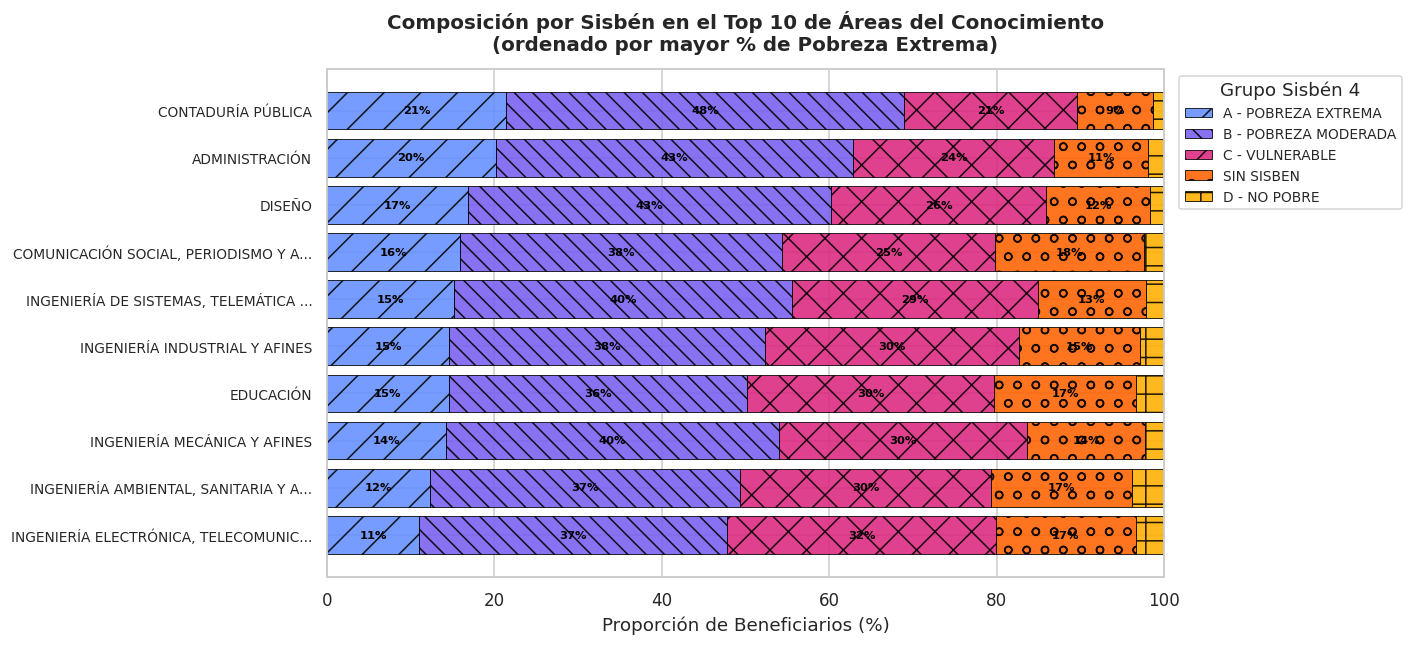

In [ ]:
#¿Hay carreras que concentran más beneficiarios de Pobreza Extrema que otras?
top10_nbc = df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].value_counts().head(10).index
df_nbc = df[df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].isin(top10_nbc)].copy()

pivot_nbc = pd.crosstab(
    df_nbc['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'],
    df_nbc['GRUPOS SISBEN 4'],
    normalize='index'
)[orden_sisben] * 100
pivot_nbc = pivot_nbc.sort_values('A - POBREZA EXTREMA', ascending=True)

etiq_nbc = [n[:35]+'...' if len(n)>35 else n for n in pivot_nbc.index]

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(pivot_nbc))
for i, (col, hatch) in enumerate(zip(orden_sisben, HATCHES)):
    vals = pivot_nbc[col].values
    bars = ax.barh(range(len(pivot_nbc)), vals, left=bottom, label=col,
                   color=PALETTE[i], edgecolor='black', linewidth=0.6, hatch=hatch, alpha=0.88)
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 7:
            ax.text(bottom[j] + v/2, j, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color='black')
    bottom += vals

ax.set_yticks(range(len(pivot_nbc)))
ax.set_yticklabels(etiq_nbc, fontsize=9)
ax.set_xlabel('Proporción de Beneficiarios (%)')
ax.set_title('Composición por Sisbén en el Top 10 de Áreas del Conocimiento\n(ordenado por mayor % de Pobreza Extrema)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Grupo Sisbén 4', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

Las áreas con mayor concentración en pobreza Extrema incluyen Educación e Ingeniería Civil, mientras que Diseño, Psicología y Comunicación Social presentan mayor proporción de grupos C y Sin Sisbén. Algunas carreras creativas tienen costos adicionales (materiales, software) que actúan como otra barrera implícita para los grupos de menor ingreso.

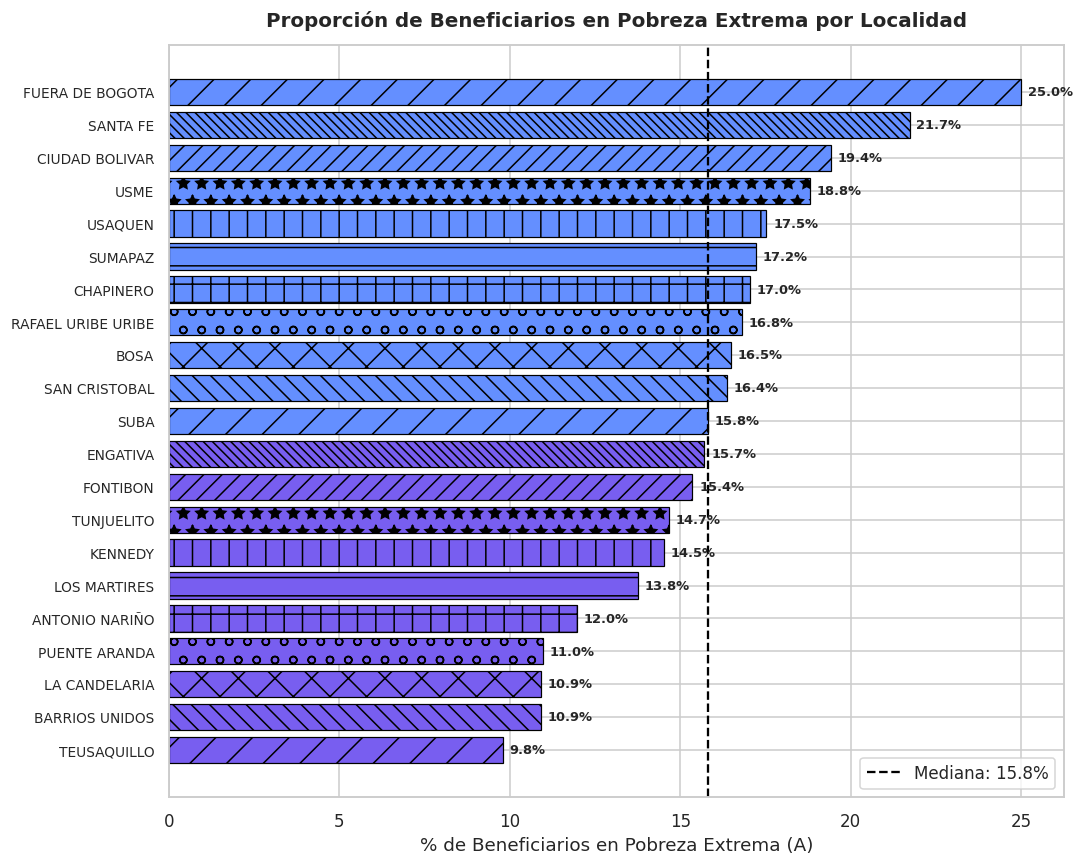

In [ ]:
#¿De qué localidades provienen más beneficiarios en situación de Pobreza Extrema?
df_loc = df[df['LOCALIDAD'] != 'SIN INFORMACION'].copy()
pivot_loc = pd.crosstab(df_loc['LOCALIDAD'], df_loc['GRUPOS SISBEN 4'])
pivot_loc['TOTAL'] = pivot_loc.sum(axis=1)
pct_a = (pivot_loc.get('A - POBREZA EXTREMA', 0) / pivot_loc['TOTAL'] * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colores = [PALETTE[0] if v >= pct_a.median() else PALETTE[1] for v in pct_a.values]
bars = ax.barh(range(len(pct_a)), pct_a.values,
               color=colores, edgecolor='black', linewidth=0.8)
for i, (bar, hatch) in enumerate(zip(bars, HATCHES * 5)):
    bar.set_hatch(hatch)
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8.5, fontweight='bold')

ax.set_yticks(range(len(pct_a)))
ax.set_yticklabels(pct_a.index, fontsize=9)
ax.set_xlabel('% de Beneficiarios en Pobreza Extrema (A)')
ax.set_title('Proporción de Beneficiarios en Pobreza Extrema por Localidad',
             fontsize=13, fontweight='bold', pad=12)
ax.axvline(pct_a.median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mediana: {pct_a.median():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

Localidades como Ciudad Bolívar, Usme y Bosa presentan la mayor proporción de beneficiarios en Pobreza Extrema, esto es consistente con los índices históricos de pobreza en Bogotá. Esto significa que la alcaldia debe fortalecer la difusión y el acompañamiento en estas zonas puede incrementar el impacto social por beneficiario.

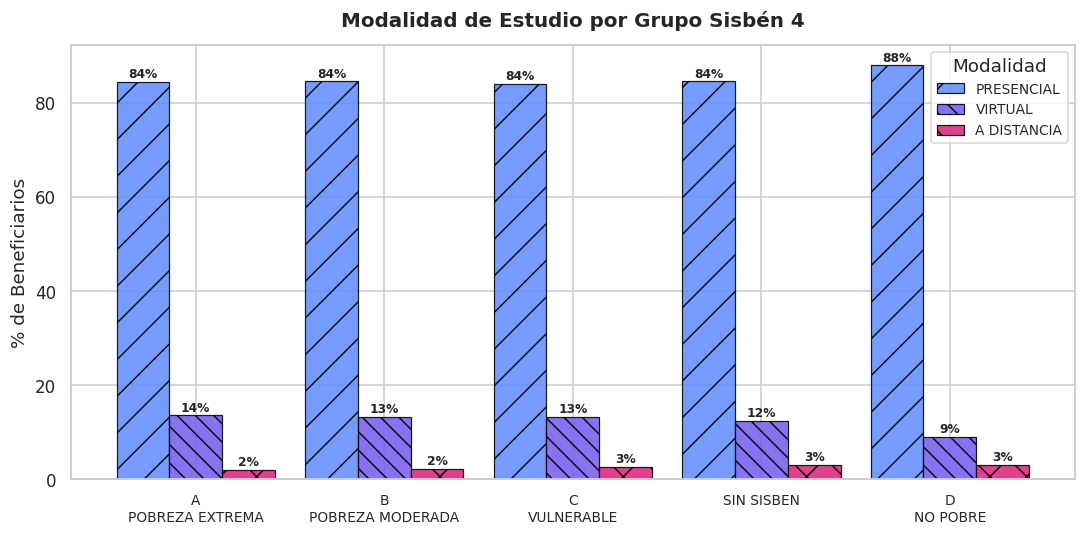

In [ ]:
#¿Los beneficiarios más vulnerables estudian más en modalidad virtual o presencial?
modalidades_principales = ['PRESENCIAL', 'VIRTUAL', 'A DISTANCIA']
df_mod = df[df['MODALIDADCORTE'].isin(modalidades_principales)].copy()

pivot_mod = pd.crosstab(df_mod['GRUPOS SISBEN 4'], df_mod['MODALIDADCORTE'], normalize='index') * 100
pivot_mod = pivot_mod.reindex([s for s in ORDEN_SISBEN if s in pivot_mod.index])
pivot_mod = pivot_mod[modalidades_principales]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_mod.index))
width = 0.28
for i, (col, hatch) in enumerate(zip(modalidades_principales, HATCHES)):
    bars = ax.bar(x + i*width, pivot_mod[col], width, label=col,
                  color=PALETTE[i], edgecolor='black', linewidth=0.8, hatch=hatch, alpha=0.88)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([s.replace(' - ', '\n') for s in pivot_mod.index], fontsize=9)
ax.set_ylabel('% de Beneficiarios')
ax.set_title('Modalidad de Estudio por Grupo Sisbén 4', fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Modalidad', fontsize=9)
plt.tight_layout()
plt.show()

La modalidad presencial domina en todos los grupos (>80%), y los grupos más vulnerables (A y B) muestran una proporción ligeramente mayor de modalidad virtual o a distancia, posiblemente porque necesitan trabajar simultáneamente; esto tiene implicaciones directas sobre las tasas de deserción y requiere estrategias de acompañamiento diferenciado.

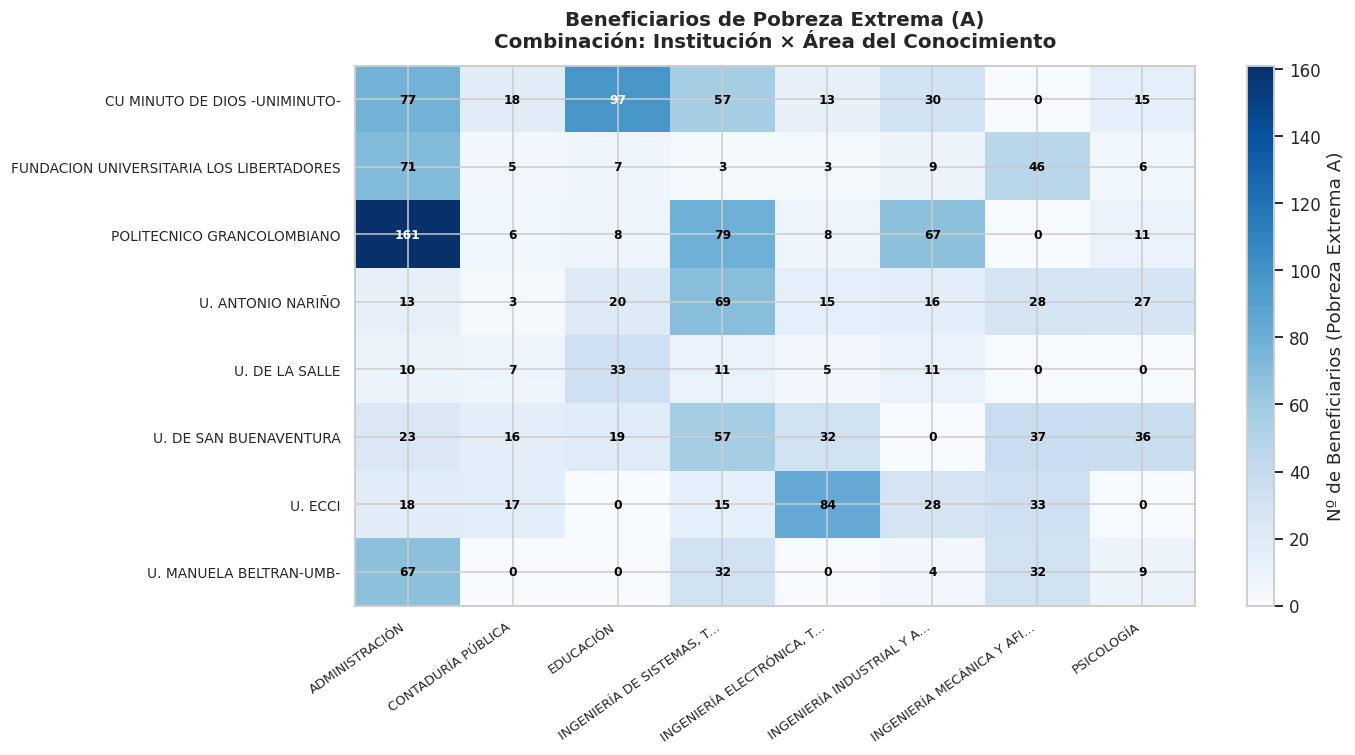

In [ ]:
#¿Qué combinaciones institución-carrera concentran más beneficiarios de Pobreza Extrema?
df_a = df[df['GRUPOS SISBEN 4'] == 'A - POBREZA EXTREMA'].copy()

top8_inst = df_a['NOMBRE INSTITUCION EDUCACION SUPERIOR'].value_counts().head(8).index
top8_nbc  = df_a['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].value_counts().head(8).index

df_heat = df_a[
    df_a['NOMBRE INSTITUCION EDUCACION SUPERIOR'].isin(top8_inst) &
    df_a['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].isin(top8_nbc)
]

heatmap_data = pd.crosstab(
    df_heat['NOMBRE INSTITUCION EDUCACION SUPERIOR'],
    df_heat['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA']
)
abrev_inst = {n: n.replace('UNIVERSIDAD ','U. ').replace('CORPORACION UNIVERSITARIA ','CU ') for n in heatmap_data.index}
heatmap_data.index = [abrev_inst.get(i,i) for i in heatmap_data.index]
etiq_col = [c[:25]+'...' if len(c)>25 else c for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Nº de Beneficiarios (Pobreza Extrema A)')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(etiq_col, rotation=35, ha='right', fontsize=8.5)
ax.set_yticklabels(heatmap_data.index, fontsize=9)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i,j]
        color_txt = 'white' if val > heatmap_data.values.max()*0.55 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=8, fontweight='bold', color=color_txt)
ax.set_title('Beneficiarios de Pobreza Extrema (A)\nCombinación: Institución × Área del Conocimiento',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Las combinaciones más frecuentes para el grupo A involucran la Universidad Distrital con Ingeniería de Sistemas y Administración, y la Universidad Pedagógica con Educación. Las celdas con valores menores en instituciones privadas revelan una brecha de acceso que el programa podría reducir con apoyos complementarios (subsidios de sostenimiento, transporte, etc).

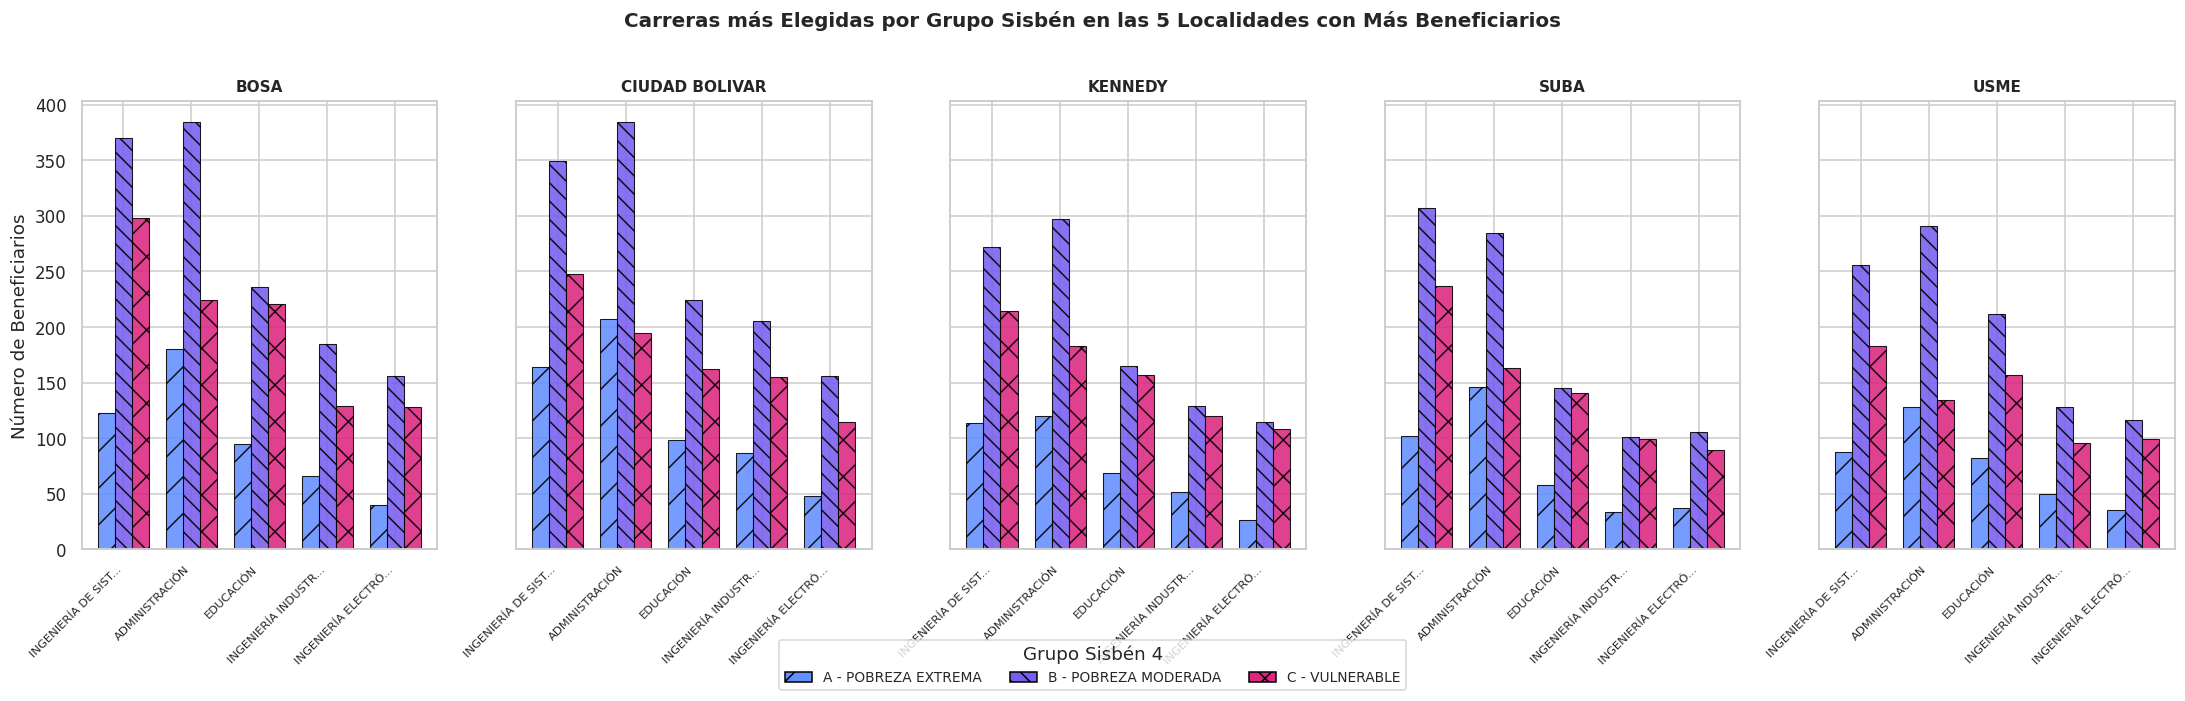

In [ ]:
#¿Varían las preferencias de carrera entre grupos Sisbén dentro de una misma localidad?
top5_loc = df['LOCALIDAD'].value_counts().head(5).index
top5_nbc = df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].value_counts().head(5).index
grupos_plot = ['A - POBREZA EXTREMA', 'B - POBREZA MODERADA', 'C - VULNERABLE']

df_loc_nbc = df[
    (df['LOCALIDAD'].isin(top5_loc)) &
    (df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].isin(top5_nbc)) &
    (df['GRUPOS SISBEN 4'].isin(grupos_plot))
].copy()

fig, axes = plt.subplots(1, len(top5_loc), figsize=(20, 6), sharey=True)
nbc_short = {n: n[:18]+'...' if len(n)>18 else n for n in top5_nbc}

for ax_i, localidad in enumerate(top5_loc):
    ax = axes[ax_i]
    df_l = df_loc_nbc[df_loc_nbc['LOCALIDAD'] == localidad]
    pivot = df_l.groupby(['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA','GRUPOS SISBEN 4']).size().unstack(fill_value=0)
    pivot = pivot[[g for g in grupos_plot if g in pivot.columns]]
    x = np.arange(len(top5_nbc))
    width = 0.25
    for i, (grupo, hatch) in enumerate(zip(grupos_plot, HATCHES)):
        if grupo in pivot.columns:
            vals = [pivot.loc[n, grupo] if n in pivot.index else 0 for n in top5_nbc]
            ax.bar(x + i*width, vals, width, label=grupo if ax_i==0 else '',
                   color=PALETTE[i], edgecolor='black', linewidth=0.7, hatch=hatch, alpha=0.88)
    ax.set_xticks(x + width)
    ax.set_xticklabels([nbc_short[n] for n in top5_nbc], rotation=45, ha='right', fontsize=7.5)
    ax.set_title(localidad, fontsize=10, fontweight='bold')
    if ax_i == 0:
        ax.set_ylabel('Número de Beneficiarios')

fig.suptitle('Carreras más Elegidas por Grupo Sisbén en las 5 Localidades con Más Beneficiarios',
             fontsize=13, fontweight='bold', y=1.02)
handles = [mpatches.Patch(facecolor=PALETTE[i], hatch=HATCHES[i], edgecolor='black', label=g)
           for i, g in enumerate(grupos_plot)]
fig.legend(handles=handles, title='Grupo Sisbén 4', loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.show()

Las preferencias de carrera son sorprendentemente uniformes entre grupos Sisbén dentro de una misma localidad; Ingeniería de Sistemas y Administración dominan independientemente del nivel de pobreza, esto indica que las decisiones vocacionales están más determinadas por la oferta disponible y la empleabilidad percibida que por el nivel socioeconómico.

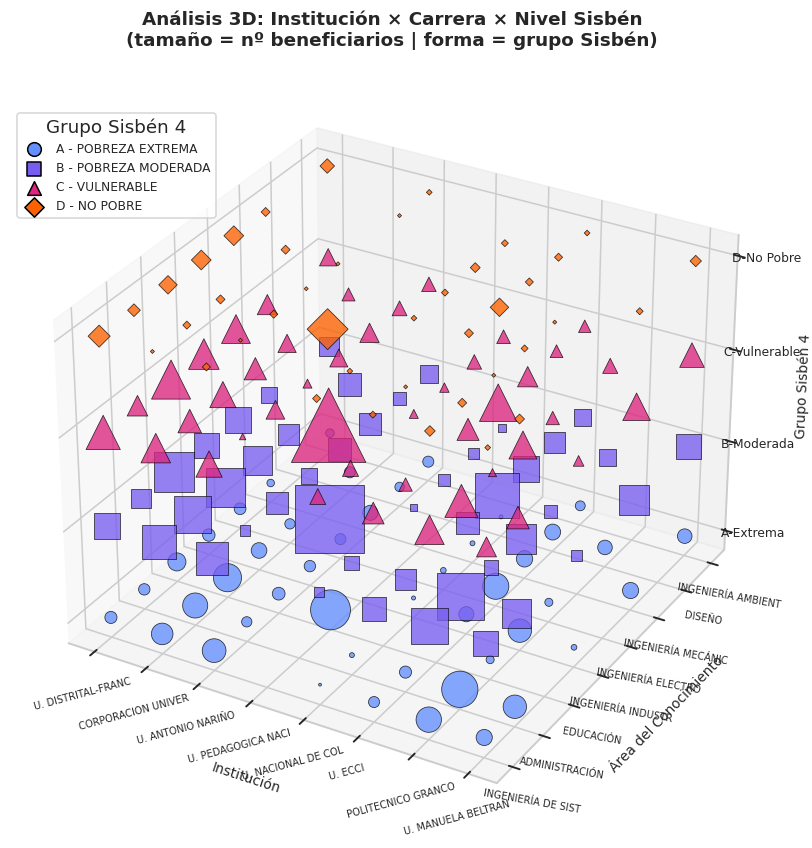


Guía de lectura del gráfico 3D:
  Eje X = Institución (top 8, de izquierda a derecha por volumen)
  Eje Y = Área del Conocimiento (top 8)
  Eje Z = Grupo Sisbén 4 (0=Extrema → 3=No Pobre)
  Tamaño del punto = número de beneficiarios en esa combinación
  Forma del marcador = grupo Sisbén (o=A, s=B, ^=C, D=D)


In [ ]:
#Visualización tridimensional que combina simultáneamente institución, carrera y nivel Sisbén. El tamaño del marcador indica el volumen de beneficiarios; la forma del marcador identifica el grupo Sisbén (sin depender del color).
from mpl_toolkits.mplot3d import Axes3D

top8_inst_3d = df['NOMBRE INSTITUCION EDUCACION SUPERIOR'].value_counts().head(8).index
top8_nbc_3d  = df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].value_counts().head(8).index
grupos_3d    = ['A - POBREZA EXTREMA','B - POBREZA MODERADA','C - VULNERABLE','D - NO POBRE']

df_3d = df[
    df['NOMBRE INSTITUCION EDUCACION SUPERIOR'].isin(top8_inst_3d) &
    df['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'].isin(top8_nbc_3d) &
    df['GRUPOS SISBEN 4'].isin(grupos_3d)
].copy()

inst_cat = pd.Categorical(df_3d['NOMBRE INSTITUCION EDUCACION SUPERIOR'], categories=top8_inst_3d)
nbc_cat  = pd.Categorical(df_3d['NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA'], categories=top8_nbc_3d)
df_3d['X_inst'] = inst_cat.codes
df_3d['Y_nbc']  = nbc_cat.codes
df_3d['Z_sbn']  = pd.Categorical(df_3d['GRUPOS SISBEN 4'], categories=grupos_3d).codes

agg_3d = df_3d.groupby(['X_inst','Y_nbc','Z_sbn','GRUPOS SISBEN 4',
                         'NOMBRE INSTITUCION EDUCACION SUPERIOR',
                         'NUCLEO BASICO DEL CONOCIMIENTO PROGRAMA']).size().reset_index(name='N')

fig = plt.figure(figsize=(14, 9))
ax3d = fig.add_subplot(111, projection='3d')

for i, (grupo, marker, color) in enumerate(zip(grupos_3d, MARKERS, PALETTE)):
    sub = agg_3d[agg_3d['GRUPOS SISBEN 4'] == grupo]
    ax3d.scatter(sub['X_inst'], sub['Y_nbc'], sub['Z_sbn'],
                 s=sub['N'] * 3.5, marker=marker, color=color,
                 edgecolors='black', linewidths=0.5, alpha=0.78, label=grupo)

inst_labels  = [n.replace('UNIVERSIDAD ','U. ')[:18] for n in top8_inst_3d]
nbc_labels   = [n[:18] for n in top8_nbc_3d]
sisben_short = ['A-Extrema','B-Moderada','C-Vulnerable','D-No Pobre']

ax3d.set_xticks(range(8)); ax3d.set_xticklabels(inst_labels, fontsize=6.5, rotation=15)
ax3d.set_yticks(range(8)); ax3d.set_yticklabels(nbc_labels,  fontsize=6.5, rotation=-10)
ax3d.set_zticks(range(4)); ax3d.set_zticklabels(sisben_short, fontsize=8)
ax3d.set_xlabel('Institución', fontsize=9, labelpad=10)
ax3d.set_ylabel('Área del Conocimiento', fontsize=9, labelpad=10)
ax3d.set_zlabel('Grupo Sisbén 4', fontsize=9, labelpad=8)
ax3d.set_title('Análisis 3D: Institución × Carrera × Nivel Sisbén\n(tamaño = nº beneficiarios | forma = grupo Sisbén)',
               fontsize=12, fontweight='bold', pad=15)

legend_handles = [
    plt.scatter([], [], marker=m, color=c, edgecolors='black', s=80, label=g)
    for g, m, c in zip(grupos_3d, MARKERS, PALETTE)
]
ax3d.legend(handles=legend_handles, title='Grupo Sisbén 4',
            loc='upper left', bbox_to_anchor=(0.0, 0.95), fontsize=8)
plt.tight_layout()
plt.show()

print("\nGuía de lectura del gráfico 3D:")
print("  Eje X = Institución (top 8, de izquierda a derecha por volumen)")
print("  Eje Y = Área del Conocimiento (top 8)")
print("  Eje Z = Grupo Sisbén 4 (0=Extrema → 3=No Pobre)")
print("  Tamaño del punto = número de beneficiarios en esa combinación")
print("  Forma del marcador = grupo Sisbén (o=A, s=B, ^=C, D=D)")

Los puntos de mayor tamaño (más beneficiarios) se concentran en Z=1 (Pobreza Moderada) y Z=2 (Vulnerable), para las primeras instituciones del eje X (universidades públicas) y las primeras carreras del eje Y (Ingeniería de Sistemas, Administración). El nivel Z=0 (Pobreza Extrema) muestra puntos más pequeños pero distribuidos de forma similar, indicando que los más pobres acceden a los mismos tipos de institución y carrera, solo en menor número.

## **💡 Fase 5: Conclusiones y Reflexiones**


### **5.1 Conclusiones del EDA**


Pregunta 1 — ¿A qué instituciones acceden los beneficiarios según su Sisbén 4?

El grupo A (Pobreza Extrema) se concentra casi exclusivamente en universidades públicas: Universidad Distrital y Universidad Pedagógica. El grupo C (Vulnerable) tiene una distribución más amplia que incluye algunas instituciones privadas de menor costo.

La diferencia es clara: a mayor pobreza, menor diversidad institucional, lo que limita las redes de contacto que genera la educación superior.

Pregunta 2 — ¿Qué áreas del conocimiento eligen los más pobres y difieren de quienes no tienen Sisbén?

Los beneficiarios del grupo A se concentran en Educación, Ingeniería de Sistemas e Ingeniería Civil, el grupo Sin Sisbén muestra mayor presencia en Diseño, Psicología y Comunicación Social, carreras con costos implícitos más altos (materiales, software, prácticas), esto sugiere que la elección vocacional no es completamente libre: está condicionada por los costos indirectos que el subsidio de matrícula no cubre.

Pregunta 3 — ¿Qué localidades concentran más vulnerabilidad y qué modalidad predomina?

Ciudad Bolívar, Usme y Bosa registran la mayor proporción de beneficiarios en Pobreza Extrema, consistente con los índices históricos de pobreza urbana en Bogotá; La modalidad presencial domina en todos los grupos (>80%), aunque los grupos A y B muestran una proporción ligeramente mayor de modalidad virtual o a distancia, probablemente por necesidad de trabajar simultáneamente.

**Hallazgos adicionales significativos**

El programa sí está bien focalizado: el 83.6% de los beneficiarios pertenecen a los grupos A, B y C, sin embargo, el 16.4% restante corresponde a Sin Sisbén (13.9%) y grupo D (2.5%), lo que representa una fuga de recursos hacia personas que no son la población objetivo prioritaria.

Quizás el hallazgo más llamativo del análisis multivariado es que las preferencias vocacionales son sorprendentemente uniformes entre grupos Sisbén dentro de una misma localidad. Ingeniería de Sistemas y Administración dominan independientemente del nivel de pobreza. Esto indica que el nivel socioeconómico no determina qué carrera se elige, sino cuántos logran llegar a cada combinación institución-carrera, lo que apunta a barreras de acceso más que a diferencias en aspiraciones.